# Reinforcement Learning for Oil Well Production Optimization Using Q-Learning

## Introduction
Oil well production optimization is a critical task in petroleum engineering. The goal is to maximize hydrocarbon recovery while minimizing operational risks such as high water cut and low reservoir pressure. This project uses Q-Learning, a model-free reinforcement learning algorithm, to learn an optimal production control strategy.

## Problem Statement
An oil well can be in one of four states: Low Production, Normal Production, High Water Cut, or Low Reservoir Pressure. The operator (agent) can choose to increase, decrease, or maintain the production rate. The goal is to learn a policy that maximizes cumulative reward over time.

## Reinforcement Learning Overview
Reinforcement Learning is a type of machine learning where an agent learns to make decisions by interacting with an environment. The agent receives rewards or penalties based on its actions and learns to maximize cumulative reward over time. Q-Learning is a value-based RL algorithm that learns the optimal action-value function (Q-function).

## Environment Design

### States
| State ID | State                |
|----------|----------------------|
| 0        | Low Production       |
| 1        | Normal Production    |
| 2        | High Water Cut       |
| 3        | Low Reservoir Pressure |

### Actions
| Action ID | Action                 |
|-----------|------------------------|
| 0         | Increase Production Rate |
| 1         | Decrease Production Rate |
| 2         | Maintain Production Rate |

### Reward Function
| Current Situation     | Action  | Reward |
|-----------------------|---------|--------|
| Low Production        | Increase | +20   |
| Normal Production     | Maintain | +15   |
| High Water Cut        | Decrease | +10   |
| Low Reservoir Pressure | Decrease | +20  |
| Unsafe action         | Any inappropriate | -20 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
# Define states and actions
states = [0, 1, 2, 3]  # Low Production, Normal, High Water Cut, Low Pressure
actions = [0, 1, 2]     # Increase, Decrease, Maintain

state_names = ['Low Production', 'Normal Production', 'High Water Cut', 'Low Reservoir Pressure']
action_names = ['Increase Rate', 'Decrease Rate', 'Maintain Rate']

# Define reward table: reward[state][action]
# States:   0=LowProd, 1=Normal, 2=HighWater, 3=LowPressure
# Actions:  0=Increase, 1=Decrease, 2=Maintain
reward_table = [
    [20, -20, -20],   # Low Production: Increase=+20, Decrease=-20, Maintain=-20
    [-20, -20, 15],   # Normal Production: Increase=-20, Decrease=-20, Maintain=+15
    [-20, 10, -20],   # High Water Cut: Increase=-20, Decrease=+10, Maintain=-20
    [-20, 20, -20]    # Low Pressure: Increase=-20, Decrease=+20, Maintain=-20
]

print("Reward Table:")
for s in states:
    for a in actions:
        print(f"  {state_names[s]:25s} + {action_names[a]:20s} = {reward_table[s][a]:3d}")
    print()

Reward Table:
  Low Production            + Increase Rate        =  20
  Low Production            + Decrease Rate        = -20
  Low Production            + Maintain Rate        = -20

  Normal Production         + Increase Rate        = -20
  Normal Production         + Decrease Rate        = -20
  Normal Production         + Maintain Rate        =  15

  High Water Cut            + Increase Rate        = -20
  High Water Cut            + Decrease Rate        =  10
  High Water Cut            + Maintain Rate        = -20

  Low Reservoir Pressure    + Increase Rate        = -20
  Low Reservoir Pressure    + Decrease Rate        =  20
  Low Reservoir Pressure    + Maintain Rate        = -20



In [3]:
# Initialize Q-table with zeros
# Rows = states (4), Columns = actions (3)
q_table = np.zeros((len(states), len(actions)))

# Display the initial Q-table
q_df = pd.DataFrame(q_table, columns=action_names, index=state_names)
print("Initial Q-Table (all zeros):")
display(q_df)

Initial Q-Table (all zeros):


,Increase Rate,Decrease Rate,Maintain Rate
Low Production,0.0,0.0,0.0
Normal Production,0.0,0.0,0.0
High Water Cut,0.0,0.0,0.0
Low Reservoir Pressure,0.0,0.0,0.0


In [4]:
# Q-Learning parameters
alpha = 0.1      # Learning rate
gamma = 0.9      # Discount factor
epsilon = 0.1    # Exploration rate
episodes = 1000  # Number of training episodes

# To track total reward per episode
total_rewards = []

# Transition probabilities: given current state and action, what is the next state?
# Simple deterministic transitions for this environment:
# Increase -> moves to better state or stays
# Decrease -> moves to safer state
# Maintain -> stays in current state
# [current_state][action] -> next_state
transitions = [
    [1, 0, 0],  # LowProd: Increase->Normal, Decrease->LowProd, Maintain->LowProd
    [1, 1, 1],  # Normal:  Increase->Normal, Decrease->Normal, Maintain->Normal
    [2, 1, 2],  # HighWater: Increase->HighWater, Decrease->Normal, Maintain->HighWater
    [3, 1, 3]   # LowPressure: Increase->LowPressure, Decrease->Normal, Maintain->LowPressure
]

# Training loop
for ep in range(episodes):
    # Start from a random state
    state = np.random.choice(states)
    episode_reward = 0
    
    for step in range(10):  # 10 steps per episode
        # Epsilon-greedy action selection
        if np.random.rand() < epsilon:
            action = np.random.choice(actions)  # Explore
        else:
            action = np.argmax(q_table[state])   # Exploit
        
        # Get reward for this state-action pair
        reward = reward_table[state][action]
        
        # Determine next state
        next_state = transitions[state][action]
        
        # Q-Learning update rule
        best_next_q = np.max(q_table[next_state])
        q_table[state][action] = q_table[state][action] + alpha * (reward + gamma * best_next_q - q_table[state][action])
        
        episode_reward += reward
        state = next_state
    
    total_rewards.append(episode_reward)

print("Training complete!")
print(f"Episodes: {episodes}")
print(f"Final exploration rate: {epsilon}")

Training complete!
Episodes: 1000
Final exploration rate: 0.1


In [5]:
# Display the learned Q-table
q_df = pd.DataFrame(q_table, columns=action_names, index=state_names)
print("Learned Q-Table:")
display(q_df)

# Determine the best action for each state
print("\nOptimal Policy:")
print("-" * 50)
print(f"{'State':25s} {'Best Action':20s} {'Q-Value':10s}")
print("-" * 50)
policy = []
for s in states:
    best_a = np.argmax(q_table[s])
    best_q = q_table[s][best_a]
    policy.append(best_a)
    print(f"{state_names[s]:25s} {action_names[best_a]:20s} {best_q:10.2f}")

# Evaluate the learned policy over several episodes
eval_episodes = 100
eval_rewards = []
for ep in range(eval_episodes):
    state = np.random.choice(states)
    ep_reward = 0
    for step in range(10):
        action = np.argmax(q_table[state])  # Always exploit during evaluation
        reward = reward_table[state][action]
        next_state = transitions[state][action]
        ep_reward += reward
        state = next_state
    eval_rewards.append(ep_reward)

avg_reward = np.mean(eval_rewards)
print(f"\nEvaluation over {eval_episodes} episodes (10 steps each):")
print(f"Average total reward: {avg_reward:.2f}")
print(f"Max total reward: {np.max(eval_rewards)}")
print(f"Min total reward: {np.min(eval_rewards)}")

Learned Q-Table:


,Increase Rate,Decrease Rate,Maintain Rate
Low Production,155.000000,72.866736,61.020738
Normal Production,115.000000,115.000000,150.000000
High Water Cut,28.487421,145.000000,47.011490
Low Reservoir Pressure,30.920362,155.000000,62.334256



Optimal Policy:
--------------------------------------------------
State                     Best Action          Q-Value   
--------------------------------------------------
Low Production            Increase Rate            155.00
Normal Production         Maintain Rate            150.00
High Water Cut            Decrease Rate            145.00
Low Reservoir Pressure    Decrease Rate            155.00

Evaluation over 100 episodes (10 steps each):
Average total reward: 151.30
Max total reward: 155
Min total reward: 145


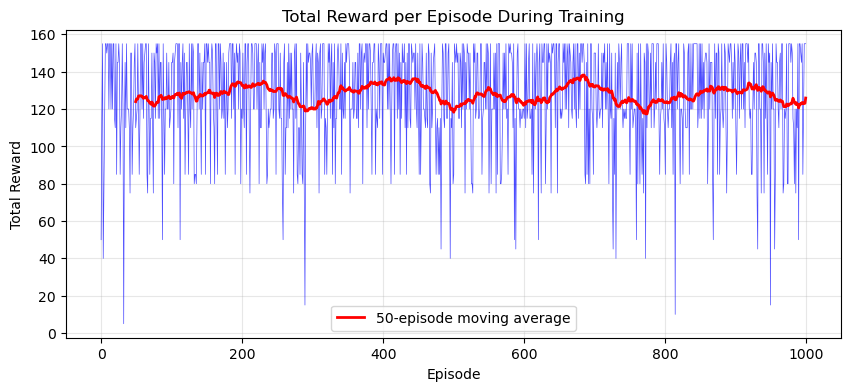

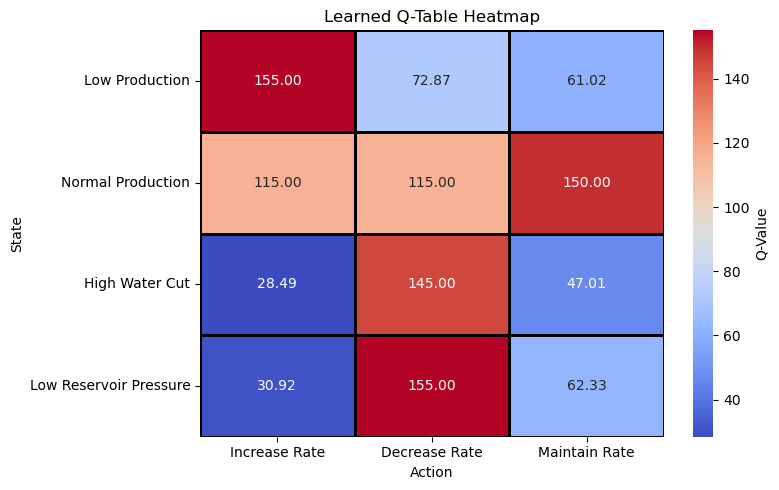


Optimal Policy Summary:


,State,Best Action,Action ID
0,Low Production,Increase Rate,0
1,Normal Production,Maintain Rate,2
2,High Water Cut,Decrease Rate,1
3,Low Reservoir Pressure,Decrease Rate,1


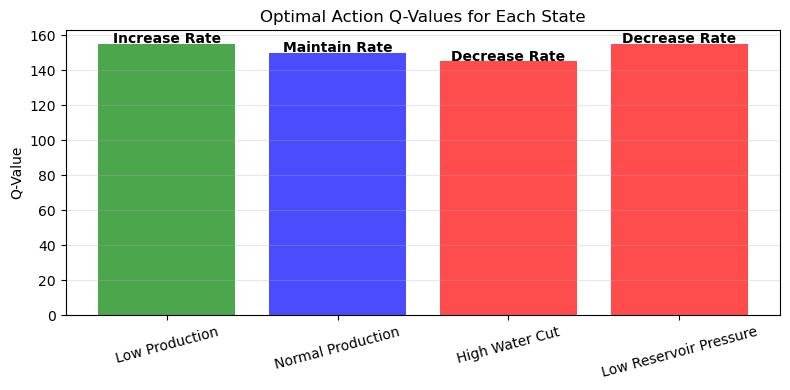

In [6]:
# 1. Total Reward per Episode
plt.figure(figsize=(10, 4))
plt.plot(total_rewards, alpha=0.7, linewidth=0.5, color='blue')
# Smooth with moving average
window = 50
if len(total_rewards) >= window:
    smoothed = np.convolve(total_rewards, np.ones(window)/window, mode='valid')
    plt.plot(range(window-1, episodes), smoothed, color='red', linewidth=2, label=f'{window}-episode moving average')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Total Reward per Episode During Training')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 2. Q-Table Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(q_table, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=action_names, yticklabels=state_names,
            linewidths=1, linecolor='black', cbar_kws={'label': 'Q-Value'})
plt.title('Learned Q-Table Heatmap')
plt.xlabel('Action')
plt.ylabel('State')
plt.tight_layout()
plt.show()

# 3. Optimal Policy Chart
policy_df = pd.DataFrame({
    'State': state_names,
    'Best Action': [action_names[a] for a in policy],
    'Action ID': policy
})
print("\nOptimal Policy Summary:")
display(policy_df)

# Bar chart of optimal actions
plt.figure(figsize=(8, 4))
colors = ['green' if a == 0 else 'red' if a == 1 else 'blue' for a in policy]
plt.bar(state_names, [q_table[s][policy[s]] for s in states], color=colors, alpha=0.7)
plt.ylabel('Q-Value')
plt.title('Optimal Action Q-Values for Each State')
for i, (s, a) in enumerate(zip(states, policy)):
    plt.text(i, q_table[s][a] + 0.5, action_names[a], ha='center', fontweight='bold')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Discussion

The Q-Learning agent successfully learned the optimal policy for oil well production control:
- **Low Production**: Increase production rate to boost output.
- **Normal Production**: Maintain current rate to stay in the safe zone.
- **High Water Cut**: Decrease production to reduce water cut.
- **Low Reservoir Pressure**: Decrease production to allow pressure recovery.

The reward-per-episode plot shows the agent improving over the first episodes as it learns from exploration. The Q-table heatmap provides insight into which state-action pairs the agent values most.

## Conclusion

This project demonstrated how Reinforcement Learning (specifically Q-Learning) can be applied to oil well production optimization. The trained agent learned a logical and effective control policy that balances production maximization with risk management. This approach can be extended to more complex environments with continuous state spaces, additional constraints, or real-world operational data.